# MobileNetV2 – Classificação CPRE (v3)

**Diagnóstico do v2 (F1=0.32):**
- `WeightedRandomSampler` causou colapso — Lithiasis F1=0.000
- MobileNetV3 com classificador muito profundo → instabilidade

**Correções no v3:**

| | v1 (F1=0.497) | v2 (F1=0.306) | v3 |
|---|---|---|---|
| GPU | ❌ CPU | ✅ | ✅ |
| Modelo | MobileNetV2 | MobileNetV3 | MobileNetV2 (estável) |
| Sampler | ❌ | WeightedRandom (colapso) | ❌ removido |
| Class weights | ✅ | ✅ | ✅ mais suaves |
| Batch size | 16 | 32 | 32 (aproveita GPU) |
| LR fase 2 | 5e-5 | 3e-5 | 1e-4 (mais agressivo) |
| Scheduler fase 1 | CosineAnnealing | OneCycleLR | OneCycleLR |
| TTA | ❌ | ✅ (piorou) | ✅ só se melhorar |

In [1]:
!pip install -q livelossplot monai torchmetrics opencv-python-headless

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 71.2 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 627.3/627.3 kB 36.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.6/155.6 kB 8.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires ipython==7.34.0, but you have ipython 9.13.0 which is incompatible.
google-colab 1.0.0 requires jupyter-server==2.14.0, but you have jupyter-server 2.12.5 which is incompatible.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.3.3 which is incompatible.
moviepy 1.0.3 requires decorator<5.0,>=4.0.2, but you have decorator 5.2.1 which is incompatible.
gcsfs 2025.3.0 requires fsspec==2025.3.0, but you have fsspec 2026.2.0 which is incompatible.


In [2]:
import torch
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Dispositivo: {device}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
else:
    raise RuntimeError('GPU não encontrada! Ativa em Settings > Accelerator > GPU T4 x2')

Dispositivo: cuda
GPU: Tesla T4


In [3]:
from livelossplot import PlotLosses
from livelossplot.outputs import MatplotlibPlot
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import cv2, os, random, time, warnings
warnings.filterwarnings('ignore')

from PIL import Image
from pathlib import Path
from datetime import datetime

from sklearn.metrics import (accuracy_score, confusion_matrix,
                              classification_report, f1_score,
                              roc_auc_score, roc_curve)
from sklearn.utils.class_weight import compute_class_weight
from sklearn.preprocessing import label_binarize

import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision.models import mobilenet_v2, MobileNet_V2_Weights
from torchmetrics.classification import MulticlassF1Score

from monai.transforms import (Activations, AsDiscrete, LoadImage, EnsureChannelFirst,
                               Resize, RandZoom, RandAdjustContrast, RandGaussianNoise,
                               RandRotate, RandFlip, RandAffine, ToTensor, Compose,
                               NormalizeIntensity, Lambda)
from monai.data import decollate_batch
from monai.metrics import ROCAUCMetric
from monai.utils import set_determinism
from monai.config import print_config

np.random.seed(0)
set_determinism(seed=0)
print_config()

2026-05-12 12:37:41.852918: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778589462.253876      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778589462.379577      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778589463.403090      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778589463.403130      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778589463.403134      57 computation_placer.cc:177] computation placer alr

MONAI version: 1.5.2
Numpy version: 2.0.2
Pytorch version: 2.10.0+cu128
MONAI flags: HAS_EXT = False, USE_COMPILED = False, USE_META_DICT = False
MONAI rev id: d18565fb3e4fd8c556707f91ac280a2dc3f681c1
MONAI __file__: /usr/local/lib/python3.12/dist-packages/monai/__init__.py

Optional dependencies:
Pytorch Ignite version: 0.5.3
ITK version: NOT INSTALLED or UNKNOWN VERSION.
Nibabel version: 5.3.3
scikit-image version: 0.25.2
scipy version: 1.16.3
Pillow version: 11.3.0
Tensorboard version: 2.19.0
gdown version: 5.2.1
TorchVision version: 0.25.0+cu128
tqdm version: 4.67.3
lmdb version: NOT INSTALLED or UNKNOWN VERSION.
psutil version: 5.9.5
pandas version: 2.3.3
einops version: 0.8.2
transformers version: 5.0.0
mlflow version: NOT INSTALLED or UNKNOWN VERSION.
pynrrd version: NOT INSTALLED or UNKNOWN VERSION.
clearml version: NOT INSTALLED or UNKNOWN VERSION.

For details about installing the optional dependencies, please visit:
    https://docs.monai.io/en/latest/installation.html#insta

In [7]:
model_path = '/kaggle/working/MIA_AP_my_models'
os.makedirs(model_path, exist_ok=True)

ROOT_PATH = '/kaggle/input/dataset/MIQR-CC-Dataset'
import os

# 1. Definimos o ROOT_PATH com o nome exato que aparece no teu painel (dataset-1)
ROOT_PATH = '/kaggle/input/datasets/filipapereira30/dataset-2'

# 2. Construímos o caminho até chegar à pasta que contém 'train', 'val' e 'test'
base_dir = os.path.join(ROOT_PATH, 'MIQR-CC-Dataset/training/dataset')

# --- TESTE DE VERIFICAÇÃO ---
print(f"A verificar caminho: {base_dir}")
if os.path.exists(os.path.join(base_dir, 'train')):
    print("✅ SUCESSO: Pasta 'train' encontrada!")
else:
    print("❌ ERRO: O caminho ainda não está correto.")
    # Se falhar, vamos listar o que existe no ROOT para ver o nome real
    if os.path.exists(ROOT_PATH):
        print("Pastas dentro do ROOT_PATH:", os.listdir(ROOT_PATH))

def get_versioned_model_name(base_path):
    base = Path(base_path)
    ts   = datetime.now().strftime('%Y%m%d_%H%M%S')
    return str(base.parent / f'{base.stem}_{ts}{base.suffix}')

# ── Hiperparâmetros ───────────────────────────────────────────────────────────
IMG_SIZE    = 224
BATCH_SIZE  = 32     # aproveita a GPU T4
EPOCHS_P1   = 10
EPOCHS_P2   = 60
LR_P1       = 1e-3
LR_P2       = 1e-4   # mais alto que v1/v2 → converge mais rápido com GPU
PATIENCE    = 15
SEED        = 42
CW_POWER    = 0.5    # suaviza os class weights (1.0=total, 0.0=sem peso)

def set_seed(seed=SEED):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False

set_seed(SEED)
print(f'Config OK | GPU | IMG={IMG_SIZE} | BATCH={BATCH_SIZE} | LR_P2={LR_P2}')

A verificar caminho: /kaggle/input/datasets/filipapereira30/dataset-2/MIQR-CC-Dataset/training/dataset
✅ SUCESSO: Pasta 'train' encontrada!
Config OK | GPU | IMG=224 | BATCH=32 | LR_P2=0.0001


In [8]:
phases = ['train', 'val', 'test']
data   = {phase: {'images': [], 'labels': []} for phase in phases}

class_names = sorted([
    x for x in os.listdir(os.path.join(base_dir, 'train'))
    if os.path.isdir(os.path.join(base_dir, 'train', x))
])
num_class = len(class_names)
print(f'Classes ({num_class}): {class_names}')

valid_exts = ('.png', '.jpg', '.jpeg', '.bmp', '.tif', '.tiff')
for phase in phases:
    for i, cname in enumerate(class_names):
        cdir = os.path.join(base_dir, phase, cname)
        imgs = [os.path.join(cdir, f) for f in os.listdir(cdir) if f.lower().endswith(valid_exts)]
        data[phase]['images'].extend(imgs)
        data[phase]['labels'].extend([i] * len(imgs))

for phase in phases:
    labels = data[phase]['labels']
    print(f'\n{phase.upper()} – {len(labels)} imagens')
    for i, c in enumerate(class_names):
        n = labels.count(i)
        print(f'  {c}: {n} ({100*n/len(labels):.1f}%)')

Classes (4): ['Biliary_Leaks', 'Lithiasis', 'Normal', 'Stricture']

TRAIN – 1067 imagens
  Biliary_Leaks: 110 (10.3%)
  Lithiasis: 505 (47.3%)
  Normal: 197 (18.5%)
  Stricture: 255 (23.9%)

VAL – 234 imagens
  Biliary_Leaks: 24 (10.3%)
  Lithiasis: 98 (41.9%)
  Normal: 59 (25.2%)
  Stricture: 53 (22.6%)

TEST – 267 imagens
  Biliary_Leaks: 17 (6.4%)
  Lithiasis: 123 (46.1%)
  Normal: 43 (16.1%)
  Stricture: 84 (31.5%)


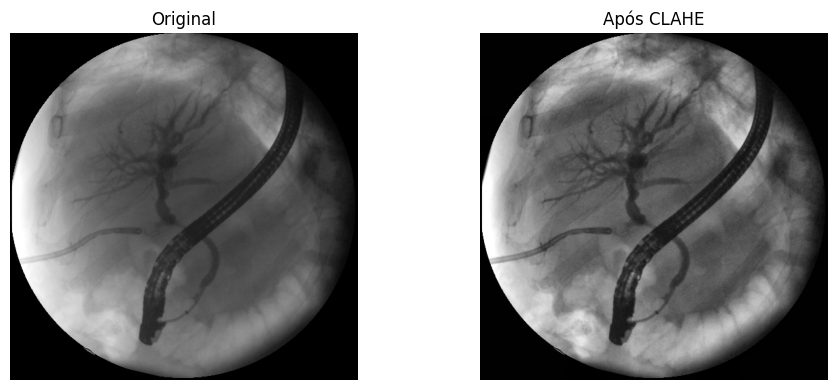

In [9]:
def apply_clahe(img_tensor):
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    arr   = img_tensor.numpy()
    out   = np.zeros_like(arr)
    for c in range(arr.shape[0]):
        ch     = (arr[c] * 255).astype(np.uint8)
        out[c] = clahe.apply(ch).astype(np.float32) / 255.0
    return torch.from_numpy(out)

def repeat_if_needed(img):
    return img.repeat(3, 1, 1) if img.shape[0] == 1 else img

# Visualização
orig = np.array(Image.open(data['train']['images'][0]).convert('L'))
enh  = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8)).apply(orig)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
ax1.imshow(orig, cmap='gray'); ax1.set_title('Original');    ax1.axis('off')
ax2.imshow(enh,  cmap='gray'); ax2.set_title('Após CLAHE'); ax2.axis('off')
plt.tight_layout(); plt.savefig(f'{model_path}/clahe.png', dpi=150); plt.show()

In [10]:
train_transforms = Compose([
    LoadImage(image_only=True),
    EnsureChannelFirst(),
    Resize((IMG_SIZE, IMG_SIZE)),
    RandFlip(spatial_axis=0, prob=0.4),
    RandFlip(spatial_axis=1, prob=0.4),
    RandRotate(range_x=20, prob=0.5),
    RandZoom(min_zoom=0.85, max_zoom=1.15, prob=0.5),
    RandAffine(shear_range=0.1, prob=0.3),
    RandAdjustContrast(prob=0.5),
    RandGaussianNoise(prob=0.3, mean=0.0, std=0.02),
    NormalizeIntensity(),
    Lambda(apply_clahe),
    Lambda(repeat_if_needed),
    ToTensor()
])

val_transforms = Compose([
    LoadImage(image_only=True),
    EnsureChannelFirst(),
    Resize((IMG_SIZE, IMG_SIZE)),
    NormalizeIntensity(),
    Lambda(apply_clahe),
    Lambda(repeat_if_needed),
    ToTensor()
])

act       = Activations(softmax=True)
to_onehot = AsDiscrete(to_onehot=num_class)
print('Transforms definidos.')

Transforms definidos.


In [11]:
class ERCPDataset(Dataset):
    def __init__(self, image_files, labels, transforms):
        self.image_files = image_files
        self.labels      = labels
        self.transforms  = transforms

    def __len__(self): return len(self.image_files)

    def __getitem__(self, idx):
        return self.transforms(self.image_files[idx]), self.labels[idx]


# ── Class weights SUAVIZADOS com CW_POWER ────────────────────────────────────
# CW_POWER=1.0 → weights originais (v1/v2)
# CW_POWER=0.5 → raiz quadrada → mais suaves, evita colapso
train_labels_np = np.array(data['train']['labels'])
cw_raw    = compute_class_weight('balanced', classes=np.arange(num_class), y=train_labels_np)
cw_smooth = cw_raw ** CW_POWER
cw_smooth = cw_smooth / cw_smooth.mean()  # renormaliza para média=1
cw_tensor = torch.tensor(cw_smooth, dtype=torch.float32).to(device)

print('Class weights (suavizados):')
for i, (raw, smooth) in enumerate(zip(cw_raw, cw_smooth)):
    print(f'  {class_names[i]}: {raw:.3f} → {smooth:.3f}')

train_ds = ERCPDataset(data['train']['images'], data['train']['labels'], train_transforms)
val_ds   = ERCPDataset(data['val']['images'],   data['val']['labels'],   val_transforms)
test_ds  = ERCPDataset(data['test']['images'],  data['test']['labels'],  val_transforms)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f'\nTrain: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}')

Class weights (suavizados):
  Biliary_Leaks: 2.425 → 1.393
  Lithiasis: 0.528 → 0.650
  Normal: 1.354 → 1.041
  Stricture: 1.046 → 0.915

Train: 1067 | Val: 234 | Test: 267


In [12]:
def build_model(freeze_backbone=True):
    model = mobilenet_v2(weights=MobileNet_V2_Weights.DEFAULT)
    in_features = model.classifier[1].in_features
    model.classifier = nn.Sequential(
        nn.Dropout(p=0.4),
        nn.Linear(in_features, 256),
        nn.ReLU(inplace=True),
        nn.Dropout(p=0.3),
        nn.Linear(256, num_class)
    )
    if freeze_backbone:
        for param in model.features.parameters():
            param.requires_grad = False
    return model.to(device)

model     = build_model(freeze_backbone=True)
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Parâmetros treináveis (fase 1): {trainable:,}')

Downloading: "https://download.pytorch.org/models/mobilenet_v2-7ebf99e0.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-7ebf99e0.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 223MB/s]

Parâmetros treináveis (fase 1): 328,964


In [13]:
def mixup_data(x, y, alpha=0.2):
    lam   = np.random.beta(alpha, alpha) if alpha > 0 else 1.0
    index = torch.randperm(x.size(0), device=x.device)
    return lam * x + (1-lam) * x[index], y, y[index], lam

def mixup_criterion(criterion, pred, y_a, y_b, lam):
    return lam * criterion(pred, y_a) + (1-lam) * criterion(pred, y_b)

loss_fn = nn.CrossEntropyLoss(weight=cw_tensor, label_smoothing=0.1)
print(f'Loss: CrossEntropyLoss (class weights suavizados + label_smoothing=0.1)')

Loss: CrossEntropyLoss (class weights suavizados + label_smoothing=0.1)


In [14]:
def train_phase(model, train_dl, val_dl, optimizer, scheduler,
                epochs, save_path, patience, use_mixup=False, phase_name=''):

    f1_metric  = MulticlassF1Score(num_classes=num_class, average='macro').to(device)
    auc_metric = ROCAUCMetric()
    liveloss   = PlotLosses(outputs=[MatplotlibPlot(figpath=f'{save_path}_{phase_name}.png')])

    best_f1, best_epoch, no_improve = -1.0, -1, 0

    print(f'\n{"="*55}')
    print(f' {phase_name}  |  epochs={epochs}  |  mixup={use_mixup}')
    print(f'{"="*55}')

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        y_pred_all = torch.tensor([], dtype=torch.float32, device=device)
        y_all      = torch.tensor([], dtype=torch.long,    device=device)

        for inputs, labels in train_dl:
            inputs, labels = inputs.to(device), labels.to(device)
            if use_mixup:
                inputs, y_a, y_b, lam = mixup_data(inputs, labels)
                outputs = model(inputs)
                loss    = mixup_criterion(loss_fn, outputs, y_a, y_b, lam)
            else:
                outputs = model(inputs)
                loss    = loss_fn(outputs, labels)

            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

            running_loss += loss.detach() * inputs.size(0)
            y_pred_all = torch.cat([y_pred_all, outputs.detach()], dim=0)
            y_all      = torch.cat([y_all, labels], dim=0)

        epoch_loss = (running_loss / len(train_dl.dataset)).item()
        train_f1   = f1_metric(y_pred_all.argmax(dim=1), y_all).item()

        model.eval()
        val_loss = 0.0
        y_pred_v = torch.tensor([], dtype=torch.float32, device=device)
        y_v      = torch.tensor([], dtype=torch.long,    device=device)

        with torch.no_grad():
            for inputs, labels in val_dl:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs  = model(inputs)
                val_loss += loss_fn(outputs, labels).detach() * inputs.size(0)
                y_pred_v  = torch.cat([y_pred_v, outputs], dim=0)
                y_v       = torch.cat([y_v, labels],       dim=0)

        val_epoch_loss = (val_loss / len(val_dl.dataset)).item()
        val_f1         = f1_metric(y_pred_v.argmax(dim=1), y_v).item()

        y_onehot   = [to_onehot(i) for i in decollate_batch(y_v, detach=False)]
        y_pred_act = [act(i) for i in decollate_batch(y_pred_v)]
        auc_metric(y_pred_act, y_onehot)
        auc_val = auc_metric.aggregate()
        auc_metric.reset()

        liveloss.update({'loss': epoch_loss, 'val_loss': val_epoch_loss,
                         'F1': train_f1,     'val_F1': val_f1})
        liveloss.send()
        scheduler.step()

        print(f'Ep {epoch+1:3d}/{epochs}  loss={epoch_loss:.4f}  '
              f'val_loss={val_epoch_loss:.4f}  F1={train_f1:.4f}  '
              f'val_F1={val_f1:.4f}  AUC={auc_val:.4f}')

        if val_f1 > best_f1:
            best_f1, best_epoch = val_f1, epoch+1
            torch.save(model.state_dict(), save_path)
            print(f'  ✔ Melhor modelo guardado (val F1={best_f1:.4f})')
            no_improve = 0
        else:
            no_improve += 1

        if no_improve >= patience:
            print(f'Early stopping ep {epoch+1}. Melhor: {best_epoch}, F1={best_f1:.4f}')
            break

    print(f'Fase concluída – melhor val F1: {best_f1:.4f}')
    return best_f1

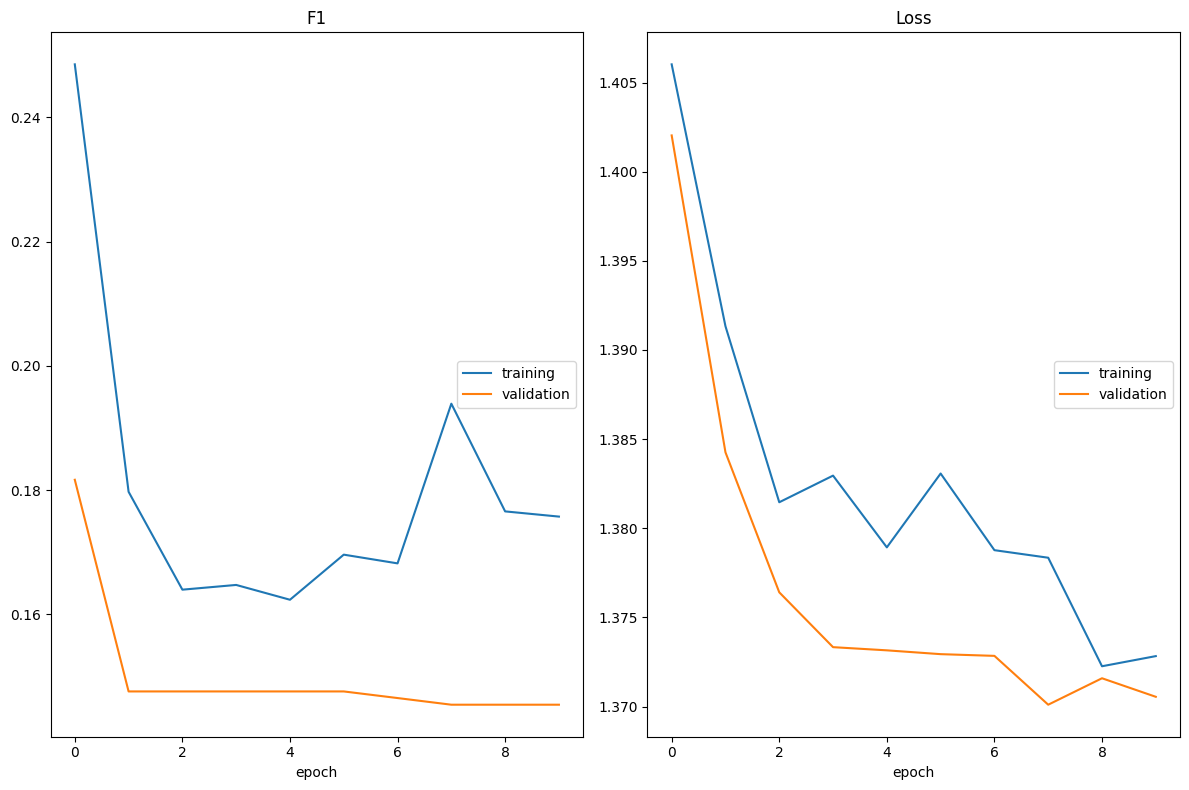

Ep  10/10  loss=1.3728  val_loss=1.3705  F1=0.1757  val_F1=0.1455  AUC=0.5334
Fase concluída – melhor val F1: 0.1817
Tempo fase 1: 213.9s


In [15]:
# ── Fase 1: Feature Extraction ────────────────────────────────────────────────
set_seed(SEED)
model      = build_model(freeze_backbone=True)
model_name = get_versioned_model_name(f'{model_path}/mobilenet_v2_v3.pth')

opt1 = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LR_P1, weight_decay=1e-4
)
sch1 = torch.optim.lr_scheduler.OneCycleLR(
    opt1, max_lr=LR_P1,
    steps_per_epoch=len(train_loader), epochs=EPOCHS_P1
)

t0 = time.perf_counter()
train_phase(model, train_loader, val_loader,
            opt1, sch1, EPOCHS_P1, model_name,
            patience=PATIENCE, use_mixup=False,
            phase_name='Fase1_FeatureExtraction')
print(f'Tempo fase 1: {time.perf_counter()-t0:.1f}s')

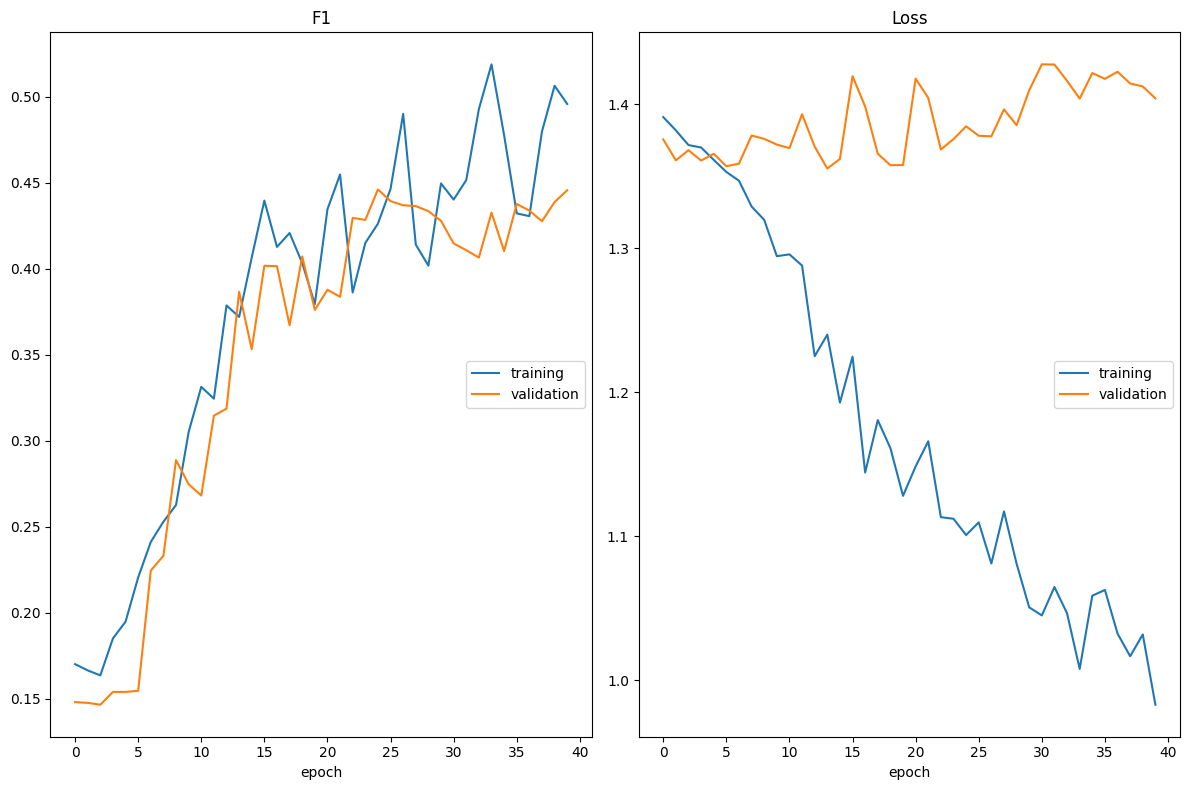

Ep  40/60  loss=0.9829  val_loss=1.4040  F1=0.4957  val_F1=0.4456  AUC=0.6805
Early stopping ep 40. Melhor: 25, F1=0.4460
Fase concluída – melhor val F1: 0.4460
Tempo fase 2: 850.1s


In [16]:
# ── Fase 2: Fine-tuning completo + Mixup ─────────────────────────────────────
model.load_state_dict(torch.load(model_name))
for param in model.parameters():
    param.requires_grad = True
print(f'Backbone descongelado. Parâmetros: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}')

opt2 = torch.optim.AdamW(model.parameters(), lr=LR_P2, weight_decay=1e-4)
sch2 = torch.optim.lr_scheduler.CosineAnnealingLR(opt2, T_max=EPOCHS_P2, eta_min=1e-7)

t0 = time.perf_counter()
train_phase(model, train_loader, val_loader,
            opt2, sch2, EPOCHS_P2, model_name,
            patience=PATIENCE, use_mixup=True,
            phase_name='Fase2_FineTuning')
print(f'Tempo fase 2: {time.perf_counter()-t0:.1f}s')

In [17]:
# ── Avaliação no conjunto de teste ────────────────────────────────────────────
model.load_state_dict(torch.load(model_name))
model.eval()

all_preds, all_labels, all_probs = [], [], []
with torch.no_grad():
    for inputs, labels in test_loader:
        outputs = model(inputs.to(device))
        probs   = F.softmax(outputs, dim=1).cpu().numpy()
        all_preds.extend(np.argmax(probs, axis=1))
        all_labels.extend(labels.numpy())
        all_probs.extend(probs)

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs  = np.array(all_probs)

f1  = f1_score(all_labels, all_preds, average='macro')
acc = accuracy_score(all_labels, all_preds)

print(f'\n{"="*55}')
print(f' Accuracy  : {acc:.4f}')
print(f' F1-macro  : {f1:.4f}')
print(f' Baseline  : 0.7380')
print(f' Delta     : {f1-0.738:+.4f}')
print(f'{"="*55}\n')
print(classification_report(all_labels, all_preds,
                             target_names=class_names, digits=4, zero_division=0))


 Accuracy  : 0.5206
 F1-macro  : 0.4771
 Baseline  : 0.7380
 Delta     : -0.2609

               precision    recall  f1-score   support

Biliary_Leaks     0.3913    0.5294    0.4500        17
    Lithiasis     0.5556    0.6504    0.5993       123
       Normal     0.4103    0.3721    0.3902        43
    Stricture     0.5574    0.4048    0.4690        84

     accuracy                         0.5206       267
    macro avg     0.4786    0.4892    0.4771       267
 weighted avg     0.5223    0.5206    0.5151       267



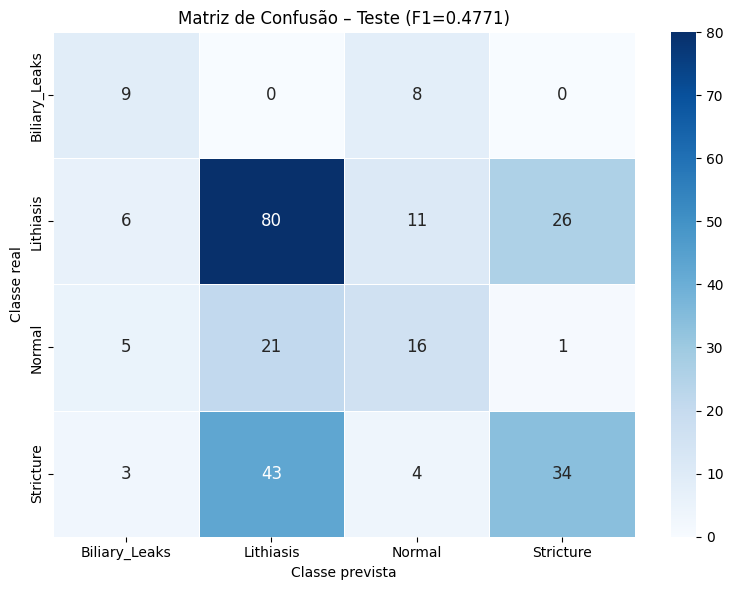

In [18]:
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names,
            linewidths=0.5, annot_kws={'size': 12})
plt.ylabel('Classe real'); plt.xlabel('Classe prevista')
plt.title(f'Matriz de Confusão – Teste (F1={f1:.4f})')
plt.tight_layout()
plt.savefig(f'{model_path}/confusion_matrix.png', dpi=200)
plt.show()

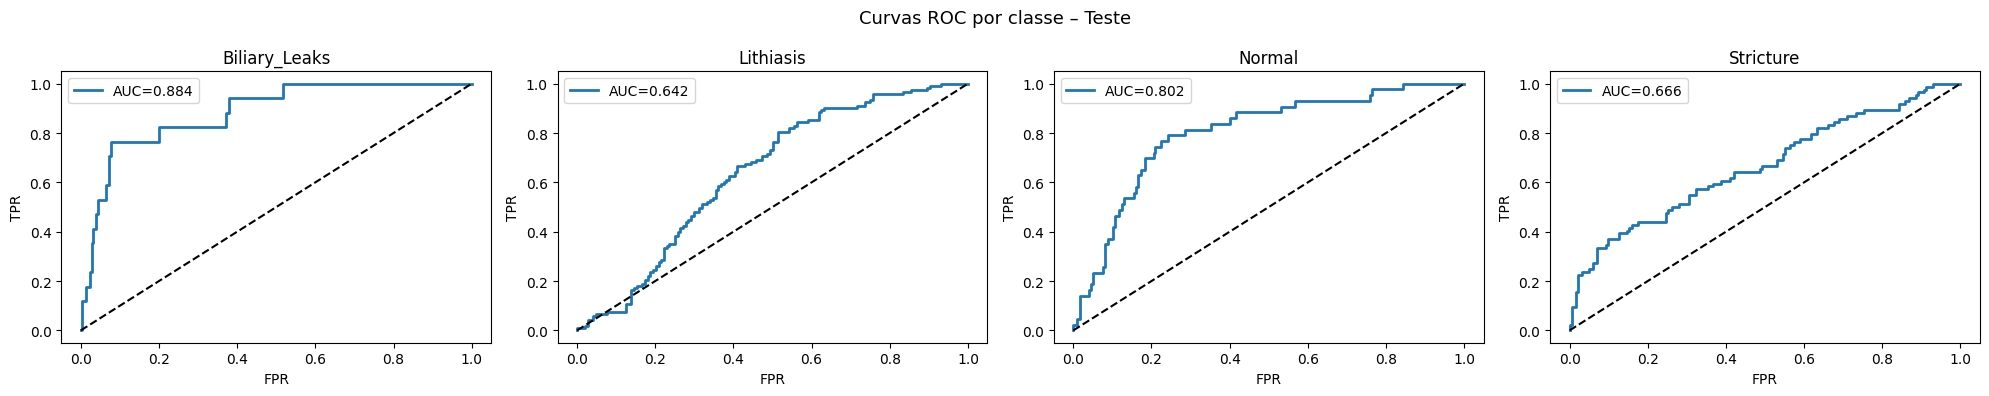

AUC-ROC macro (OvR): 0.7484


In [19]:
y_bin = label_binarize(all_labels, classes=np.arange(num_class))
fig, axes = plt.subplots(1, num_class, figsize=(5*num_class, 4))
for i, (ax, cname) in enumerate(zip(axes, class_names)):
    fpr, tpr, _ = roc_curve(y_bin[:, i], all_probs[:, i])
    auc_val = roc_auc_score(y_bin[:, i], all_probs[:, i])
    ax.plot(fpr, tpr, lw=2, label=f'AUC={auc_val:.3f}')
    ax.plot([0,1],[0,1],'k--'); ax.set_title(cname)
    ax.set_xlabel('FPR'); ax.set_ylabel('TPR'); ax.legend()
plt.suptitle('Curvas ROC por classe – Teste', fontsize=13)
plt.tight_layout()
plt.savefig(f'{model_path}/roc_curves.png', dpi=150)
plt.show()
mean_auc = roc_auc_score(y_bin, all_probs, average='macro', multi_class='ovr')
print(f'AUC-ROC macro (OvR): {mean_auc:.4f}')

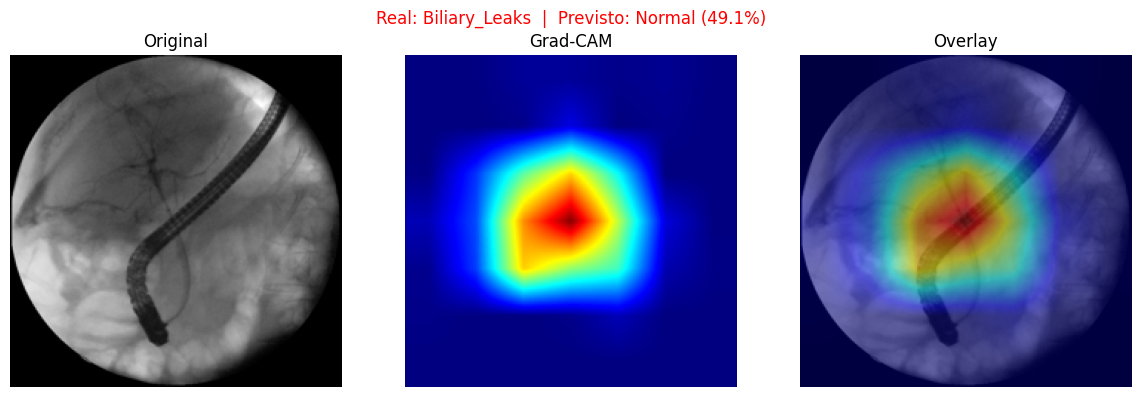

Guardado: /kaggle/working/MIA_AP_my_models/gradcam/gradcam_Biliary_Leaks_0.png


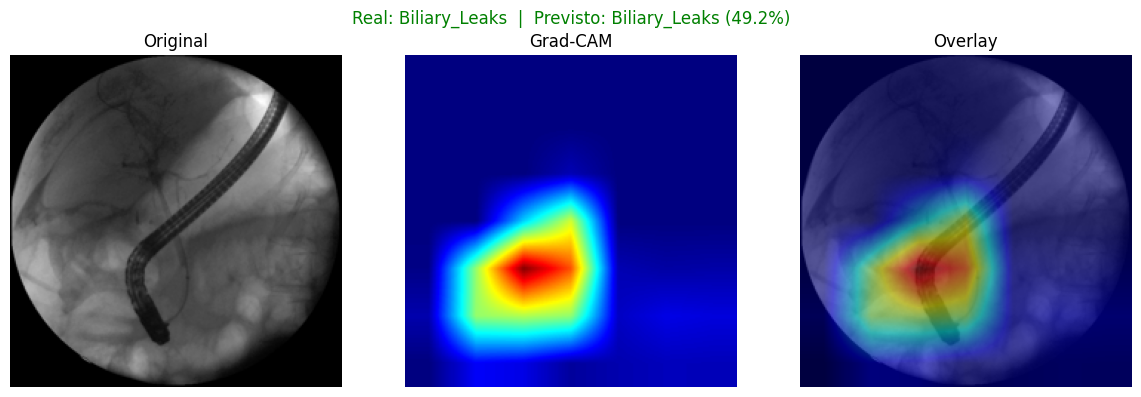

Guardado: /kaggle/working/MIA_AP_my_models/gradcam/gradcam_Biliary_Leaks_1.png


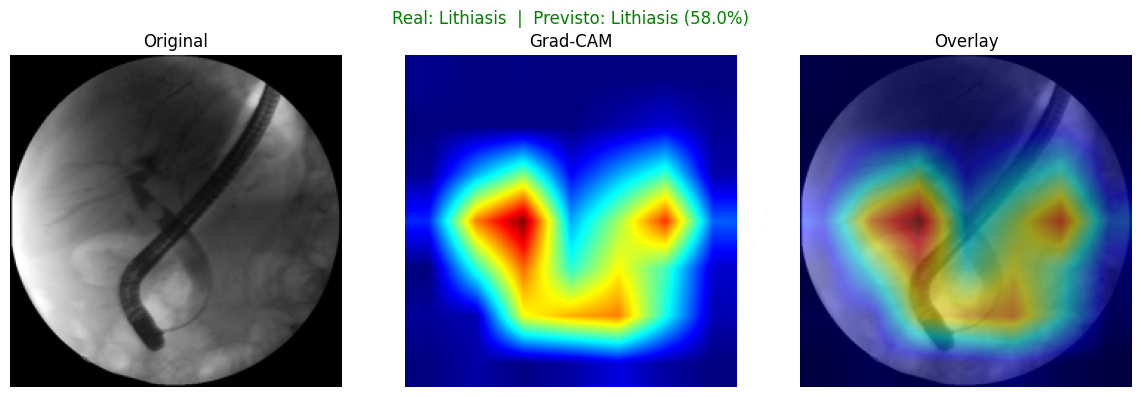

Guardado: /kaggle/working/MIA_AP_my_models/gradcam/gradcam_Lithiasis_0.png


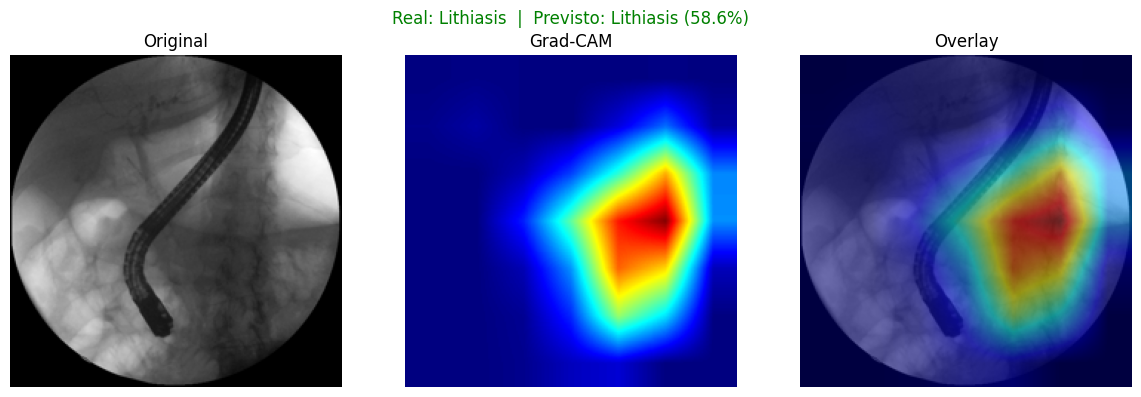

Guardado: /kaggle/working/MIA_AP_my_models/gradcam/gradcam_Lithiasis_1.png


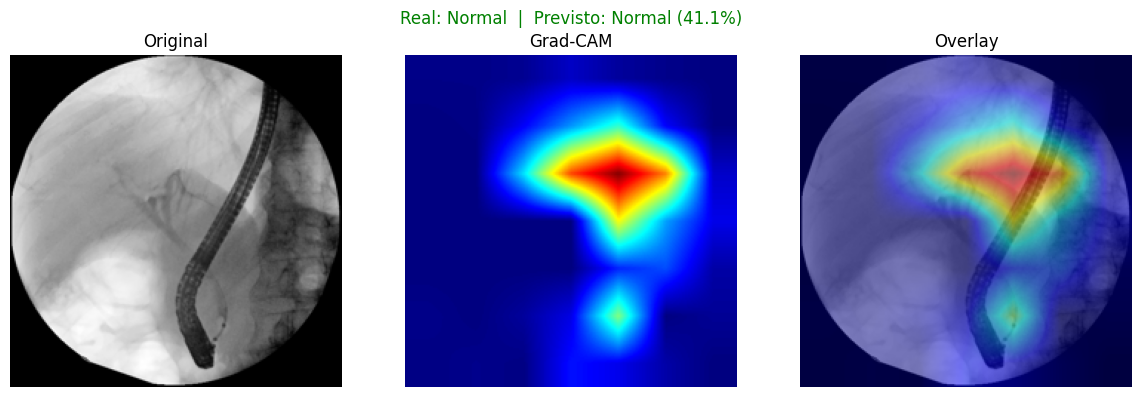

Guardado: /kaggle/working/MIA_AP_my_models/gradcam/gradcam_Normal_0.png


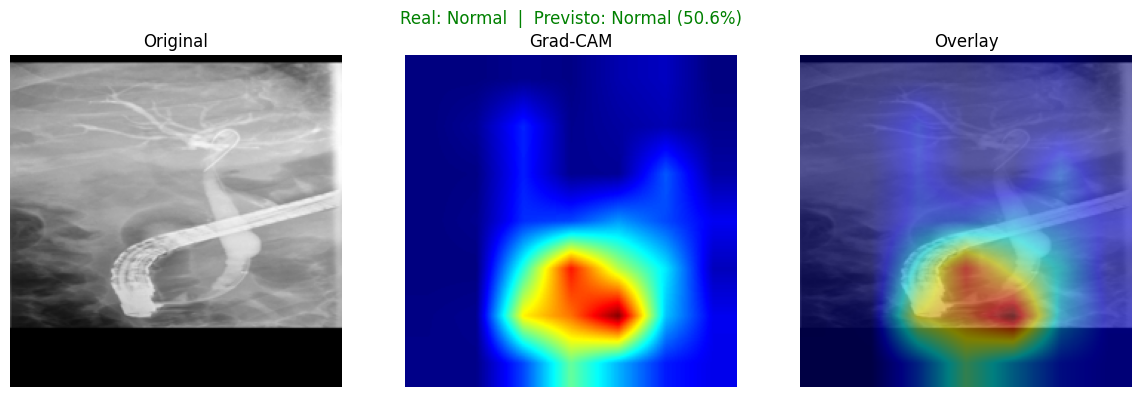

Guardado: /kaggle/working/MIA_AP_my_models/gradcam/gradcam_Normal_1.png


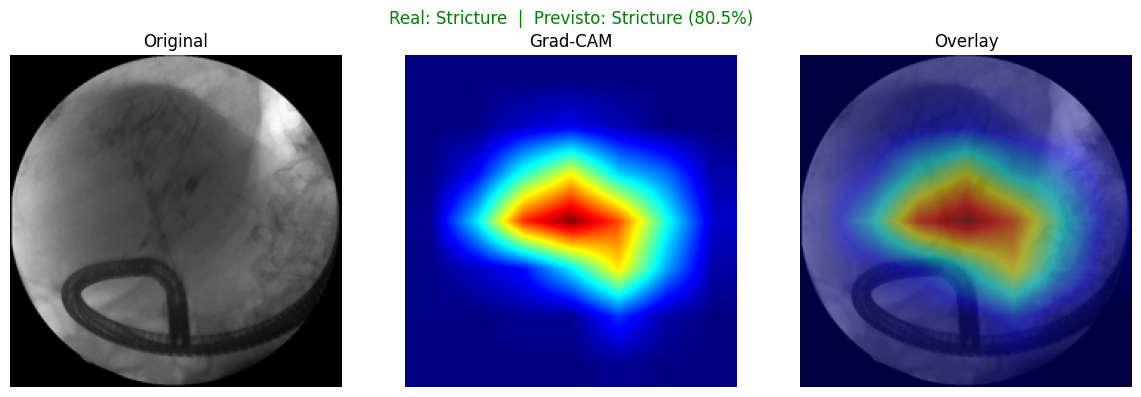

Guardado: /kaggle/working/MIA_AP_my_models/gradcam/gradcam_Stricture_0.png


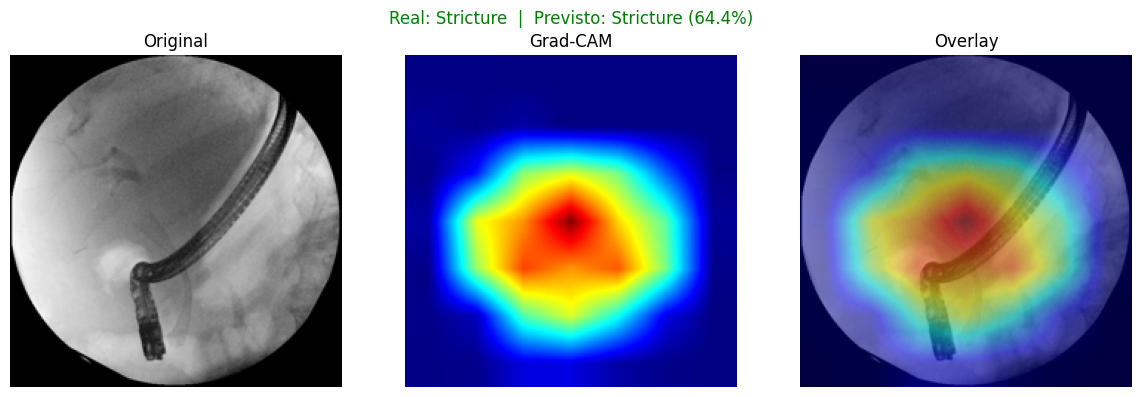

Guardado: /kaggle/working/MIA_AP_my_models/gradcam/gradcam_Stricture_1.png


In [20]:
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.activations = None
        self.gradients   = None
        target_layer.register_forward_hook(
            lambda m, i, o: setattr(self, 'activations', o.detach()))
        target_layer.register_backward_hook(
            lambda m, gi, go: setattr(self, 'gradients', go[0].detach()))

    def generate(self, input_tensor, class_idx=None):
        self.model.eval()
        x   = input_tensor.unsqueeze(0).to(device).requires_grad_(True)
        out = self.model(x)
        if class_idx is None:
            class_idx = out.argmax(dim=1).item()
        self.model.zero_grad()
        oh = torch.zeros_like(out); oh[0, class_idx] = 1.0
        out.backward(gradient=oh)
        weights = self.gradients.mean(dim=[2, 3], keepdim=True)
        cam = F.relu((weights * self.activations).sum(dim=1, keepdim=True))
        cam = cam.squeeze().cpu().numpy()
        if cam.max() > cam.min():
            cam = (cam - cam.min()) / (cam.max() - cam.min())
        return cam, class_idx, F.softmax(out, dim=1)[0, class_idx].item()


gradcam = GradCAM(model, target_layer=model.features[-1])

def show_gradcam(img_path, true_label, save_path=None):
    img_tensor = val_transforms(img_path)
    cam, pred_idx, prob = gradcam.generate(img_tensor)
    raw     = np.array(Image.open(img_path).convert('L').resize((IMG_SIZE, IMG_SIZE)))
    raw_rgb = cv2.cvtColor(raw, cv2.COLOR_GRAY2RGB)
    cam_r   = cv2.resize(cam, (IMG_SIZE, IMG_SIZE))
    heatmap = cv2.applyColorMap((cam_r*255).astype(np.uint8), cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)
    overlay = (0.5*raw_rgb + 0.5*heatmap).astype(np.uint8)
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    axes[0].imshow(raw, cmap='gray'); axes[0].set_title('Original');  axes[0].axis('off')
    axes[1].imshow(heatmap);          axes[1].set_title('Grad-CAM');  axes[1].axis('off')
    axes[2].imshow(overlay);          axes[2].set_title('Overlay');   axes[2].axis('off')
    cor = 'green' if pred_idx == true_label else 'red'
    plt.suptitle(f'Real: {class_names[true_label]}  |  Previsto: {class_names[pred_idx]} ({prob:.1%})',
                 fontsize=12, color=cor)
    plt.tight_layout()
    if save_path: plt.savefig(save_path, dpi=200)
    plt.show()

os.makedirs(f'{model_path}/gradcam', exist_ok=True)
for ci, cname in enumerate(class_names):
    imgs = [(p,l) for p,l in zip(data['test']['images'], data['test']['labels']) if l == ci]
    for k, (path, lbl) in enumerate(imgs[:2]):
        save_file = f'{model_path}/gradcam/gradcam_{cname}_{k}.png'
        show_gradcam(path, lbl, save_path=save_file)
        print(f'Guardado: {save_file}')

In [21]:
print('='*60)
print('RESUMO COMPARATIVO')
print('='*60)
print(f'  v0 (professor, CPU)  test F1 = 0.4564')
print(f'  v1 (CPU)             test F1 = 0.4973')
print(f'  v2 (GPU, colapso)    test F1 = 0.3063')
print(f'  v3 (GPU, corrigido)  test F1 = {f1:.4f}')
print(f'  Baseline artigo              = 0.7380')
print(f'  Delta vs baseline            = {f1-0.738:+.4f}')
print('='*60)

RESUMO COMPARATIVO
  v0 (professor, CPU)  test F1 = 0.4564
  v1 (CPU)             test F1 = 0.4973
  v2 (GPU, colapso)    test F1 = 0.3063
  v3 (GPU, corrigido)  test F1 = 0.4771
  Baseline artigo              = 0.7380
  Delta vs baseline            = -0.2609
